<a href="https://colab.research.google.com/github/ahmedhussein2001/DNN/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Airline_Delay_Cause.xls')
pd.set_option('display.max_column',None)
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [4]:
df.dropna(inplace=True)

In [5]:
df.drop(columns=['carrier','carrier_name', 'airport', 'airport_name'], inplace=True)

# Binary Classification

In [6]:
df['weather_delay'].min() , df['weather_delay'].max()

(0.0, 57707.0)

In [7]:
df['WD'] = df['weather_delay'].apply(lambda x: 1 if x > 100 else 0)
df['WD'].value_counts()

,count
WD,
0,215111
1,102150


In [8]:
x = df.drop(columns=['WD'], axis=1)
y = df['WD']

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [10]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((222082, 17), (95179, 17), (222082,), (95179,))

In [11]:
import tensorflow as tf
import keras

In [12]:
DNN = keras.models.Sequential([
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

In [13]:
DNN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
model_ =DNN.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8992 - loss: 3.2732 - val_accuracy: 0.9885 - val_loss: 0.0492
Epoch 2/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9908 - loss: 0.0479 - val_accuracy: 0.9949 - val_loss: 0.0133
Epoch 3/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9934 - loss: 0.0244 - val_accuracy: 0.9979 - val_loss: 0.0081
Epoch 4/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9982 - val_loss: 0.0078
Epoch 5/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.9928 - val_loss: 0.0235
Epoch 6/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9983 - val_loss: 0.0058
Epoch 7/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9971 - val_loss: 0.0100
Epoch 8/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9944 - loss: 0

In [15]:
DNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,853 (112.71 KB)

 Trainable params: 9,617 (37.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,236 (75.14 KB)

In [16]:
y_pred = DNN.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

2975/2975 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [17]:
print(y_pred[:5])
print()
print(y_test[:5])

[[1]
 [0]
 [0]
 [0]
 [1]]

275895    1
119384    0
117327    0
53842     0
153312    1
Name: WD, dtype: int64


In [18]:
model_loss, model_accuracy = DNN.evaluate(x_test, y_test)
print(f"Model Loss: {model_loss}")
print(f"Model Accuracy: {model_accuracy}")

2975/2975 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9751 - loss: 0.0509
Model Loss: 0.051133643835783005
Model Accuracy: 0.9756248593330383


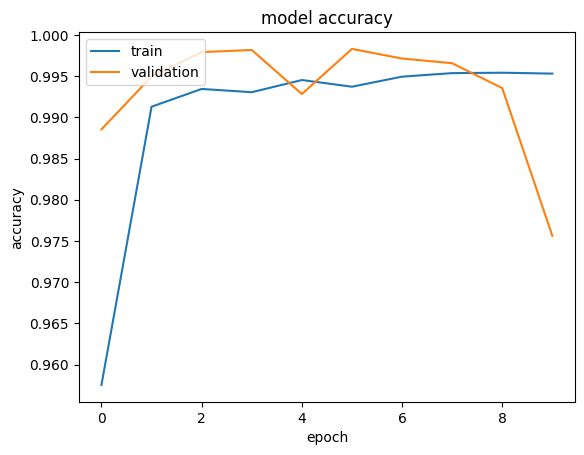

In [19]:
plt.plot(model_.history['accuracy'])
plt.plot(model_.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

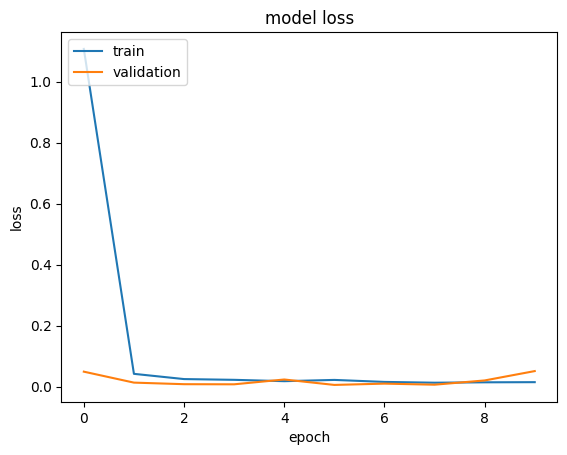

In [20]:
plt.plot(model_.history['loss'])
plt.plot(model_.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [21]:
from sklearn.metrics import classification_report
ClassificationReport = classification_report(y_test,y_pred)
print('Classification Report is : \n', ClassificationReport )

Classification Report is : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     64451
           1       0.95      0.97      0.96     30728

    accuracy                           0.98     95179
   macro avg       0.97      0.97      0.97     95179
weighted avg       0.98      0.98      0.98     95179



# Multi_Classification

In [22]:
data = pd.read_csv('Airline_Delay_Cause.xls')
data.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [23]:
data.dropna(inplace=True)

In [24]:
data.drop(columns=['carrier','carrier_name', 'airport', 'airport_name'], inplace=True)

In [25]:
def Value(x) :
  if x <=50 :
    return 0
  elif x <= 100 :
    return 1
  elif x <= 200 :
    return 2
  else :
    return 3
data['WDCase'] = data['weather_delay'].apply(lambda x : Value(x))

data['WDCase'].value_counts()


,count
WDCase,
0,183871
3,68251
2,33899
1,31240


In [26]:
x = data.drop(columns=['WDCase'], axis=1)
y = data['WDCase']

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [28]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((222082, 17), (95179, 17), (222082,), (95179,))

In [29]:
y_cat = tf.keras.utils.to_categorical(y_train)
y[:20]

,WDCase
0,0
1,0
2,0
3,0
4,0
5,1
6,3
7,0
8,0
9,0


In [30]:
DNN_ = keras.models.Sequential([
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(4, activation='softmax'),
])

In [31]:
DNN_.compile(optimizer='adam' , loss='categorical_crossentropy' , metrics=['accuracy'])

In [39]:
y_test_cat = tf.keras.utils.to_categorical(y_test)

model_1 = DNN_.fit(x_train, y_cat, epochs=10, batch_size=32, validation_data=(x_test, y_test_cat))

Epoch 1/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9869 - loss: 0.0372 - val_accuracy: 0.9927 - val_loss: 0.0187
Epoch 2/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9893 - loss: 0.0287 - val_accuracy: 0.9892 - val_loss: 0.0254
Epoch 3/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9882 - loss: 0.0341 - val_accuracy: 0.9873 - val_loss: 0.0297
Epoch 4/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9878 - loss: 0.0348 - val_accuracy: 0.9933 - val_loss: 0.0155
Epoch 5/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9888 - loss: 0.0301 - val_accuracy: 0.9939 - val_loss: 0.0173
Epoch 6/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9889 - loss: 0.0290 - val_accuracy: 0.9770 - val_loss: 0.0537
Epoch 7/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9895 - loss: 0.0285 - val_accuracy: 0.9890 - val_loss: 0.0245
Epoch 8/10
6941/6941 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9871 - loss: 0

In [40]:
DNN_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,438 (115.00 KB)

 Trainable params: 9,812 (38.33 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,626 (76.67 KB)

In [41]:
y_predict = DNN_.predict(x_test)
y_predict = np.argmax(y_predict, axis=1)

2975/2975 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [42]:
print(y_predict[:10])
print()
print(y_test_cat[:10])

[3 1 1 0 2 2 3 3 1 1]

[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


In [43]:
model_loss, model_accuracy = DNN_.evaluate(x_test, y_test_cat)
print(f"Model Loss: {model_loss}")
print(f"Model Accuracy: {model_accuracy}")

2975/2975 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9929 - loss: 0.0181
Model Loss: 0.01857868768274784
Model Accuracy: 0.9927399754524231


Text(0.5, 0, 'epoch')

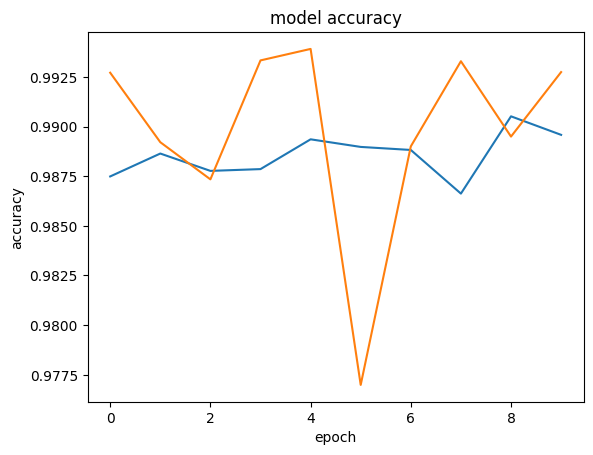

In [44]:
plt.plot(model_1.history['accuracy'])
plt.plot(model_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

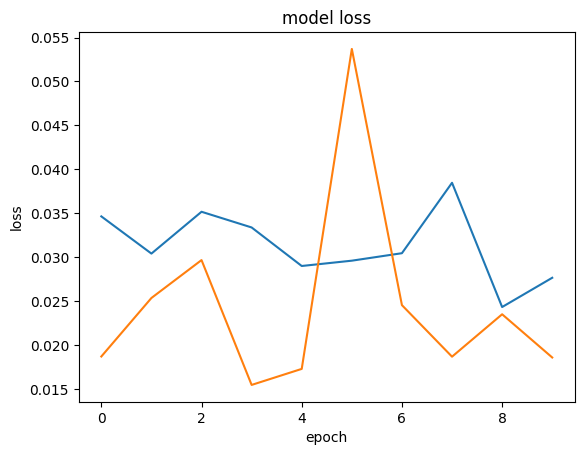

In [45]:
plt.plot(model_1.history['loss'])
plt.plot(model_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

In [46]:
from sklearn.metrics import classification_report
ClassificationReport = classification_report(y_test,y_predict)
print('Classification Report is : \n', ClassificationReport )

Classification Report is : 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     55160
           1       1.00      0.95      0.97      9291
           2       0.97      0.99      0.98     10214
           3       1.00      0.99      1.00     20514

    accuracy                           0.99     95179
   macro avg       0.99      0.98      0.99     95179
weighted avg       0.99      0.99      0.99     95179

